# Layer × layer CKA of J-lens vectors

Replicates Figure 27 of [*Verbalizable Representations Form a Global Workspace
in Language Models*](https://transformer-circuits.pub/2026/workspace/index.html)
on four open-weights models: for each model, the layer × layer
centered-kernel-alignment (CKA) matrix of the layers' J-lens vector geometry.

**J-lens vectors.** The Jacobian lens reads out a layer-$\ell$ residual $h$ as
$\mathrm{unembed}(J_\ell h)$ with $J_\ell = \mathbb{E}[\partial h_{final} /
\partial h_\ell]$, so the lens logit of token $t$ is $u_t^\top J_\ell h$. The
**J-lens vector** of token $t$ at layer $\ell$ is therefore $J_\ell^\top u_t$
— row $t$ of $W_U J_\ell$ — the direction in layer-$\ell$ residual space that
reads out as $t$. Rows are unit-normalized and column-centered before
comparison.

**CKA.** For each pair of layers we compare the direction sets with linear CKA
in its feature form,

$$\mathrm{CKA}(X, Y) = \frac{\lVert X^\top Y \rVert_F^2}
{\lVert X^\top X \rVert_F \, \lVert Y^\top Y \rVert_F},$$

on the centered `[n_tokens, d_model]` feature matrices. This is identical to
Gram-matrix linear CKA but only ever materializes $d \times d$ products, which
is what makes full-vocabulary comparison tractable (a token-level Gram matrix
would have $\mathrm{vocab}^2$ entries).

**Final layer.** The fitted lenses cover layers $0..n-2$. At the final layer
the transport is exactly the identity: the last block's output at position $p$
feeds nothing but the unembedding at $p$ itself, so
$\partial h_{final}[p'] / \partial h_{final}[p] = \delta_{pp'} I$ for every
prompt. We append that layer with $J = I$; its J-lens vectors are the raw
unembedding rows.

**Footprint.** Only the checkpoint shard holding the unembedding is ever
downloaded (never the full model), and CKA features are rebuilt on the fly in
row-blocks, so peak GPU memory stays flat in the number of layers even at
70B scale.

| model | unembedding | lens fit |
|---|---|---|
| [google/gemma-3-1b-it](https://huggingface.co/google/gemma-3-1b-it) | tied, 262k × 1152 | 460 prompts |
| [Qwen/Qwen3.5-4B](https://huggingface.co/Qwen/Qwen3.5-4B) | tied, 248k × 2560 | 1000 prompts |
| [Qwen/Qwen3.6-27B](https://huggingface.co/Qwen/Qwen3.6-27B) | untied, 248k × 5120 | 1000 prompts |
| [meta-llama/Llama-3.3-70B-Instruct](https://huggingface.co/meta-llama/Llama-3.3-70B-Instruct) | untied, 128k × 8192 | 125 prompts |

All lenses are WikiText-103 fits from
[neuronpedia/jacobian-lens](https://huggingface.co/neuronpedia/jacobian-lens).


In [1]:
import json
import os
import time

import torch
import transformers
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import EntryNotFoundError, disable_progress_bars
from safetensors import safe_open

import jlens
from jlens.vis import _meaningful_token_mask

disable_progress_bars()
torch.set_float32_matmul_precision("high")  # TF32; CKA is insensitive to it

LENS_REPO = "neuronpedia/jacobian-lens"
MODELS = [
    ("gemma-3-1b-it", "google/gemma-3-1b-it",
     "gemma-3-1b-it/jlens/Salesforce-wikitext/gemma-3-1b-it_jacobian_lens.pt"),
    ("Qwen3.5-4B", "Qwen/Qwen3.5-4B",
     "qwen3.5-4b/jlens/Salesforce-wikitext/Qwen3.5-4B_jacobian_lens_n1000.pt"),
    ("Qwen3.6-27B", "Qwen/Qwen3.6-27B",
     "qwen3.6-27b/jlens/Salesforce-wikitext/Qwen3.6-27B_jacobian_lens_n1000.pt"),
    ("Llama-3.3-70B-Instruct", "meta-llama/Llama-3.3-70B-Instruct",
     "llama3.3-70b-it/jlens/Salesforce-wikitext/Llama-3.3-70B-Instruct_jacobian_lens.pt"),
]


In [2]:
def fetch(source, filename):
    """Path to `filename` from a local checkpoint dir or an HF repo id;
    None if the file does not exist."""
    if os.path.isdir(source):
        path = os.path.join(source, filename)
        return path if os.path.exists(path) else None
    try:
        return hf_hub_download(source, filename)
    except EntryNotFoundError:
        return None


def unembed_key(keys):
    """Tensor name of the unembedding: `lm_head.weight` when present, else the
    input embedding (tied unembedding), under any submodule prefix."""
    keys = list(keys)
    return next((k for k in keys if k.endswith("lm_head.weight")),
                next(k for k in keys if k.endswith("embed_tokens.weight")))


def load_unembedding(source, device="cuda"):
    """W_U [vocab, d_model] (fp32 on `device`) and the model's layer count,
    downloading only the shard that holds the unembedding."""
    cfg = json.load(open(fetch(source, "config.json")))
    cfg = cfg.get("text_config", cfg)  # multimodal wrappers nest the text dims
    index_path = fetch(source, "model.safetensors.index.json")
    if index_path is not None:
        weight_map = json.load(open(index_path))["weight_map"]
        key = unembed_key(weight_map)
        shard_path = fetch(source, weight_map[key])
    else:  # single-file checkpoint
        shard_path = fetch(source, "model.safetensors")
        with safe_open(shard_path, framework="pt") as f:
            key = unembed_key(f.keys())
    with safe_open(shard_path, framework="pt", device=device) as f:
        W_U = f.get_tensor(key).float()
    return W_U, cfg["num_hidden_layers"]


In [3]:
@torch.no_grad()
def lens_directions(W_U, jacobians, layer, ids=None):
    """Centered J-lens vectors at `layer`: rows of W_U @ J_l, unit-normalized,
    then column-centered. Layers absent from `jacobians` (the final layer) use
    the identity transport. `ids` restricts to a token subset."""
    W = W_U if ids is None else W_U[ids]
    V = W @ jacobians[layer].to(W_U.device) if layer in jacobians else W.clone()
    V = torch.nn.functional.normalize(V, dim=-1)
    V -= V.mean(0)
    return V


@torch.no_grad()
def cka_matrix(W_U, jacobians, layers, ids=None, row_block=6):
    """Pairwise linear CKA (feature form) between the layers' J-lens direction
    sets. A block of `row_block` row-features is held on GPU while column
    features stream past it, rebuilt on the fly — a rebuild is one
    [vocab, d] @ [d, d] matmul, the same cost as one pair product."""
    L = len(layers)
    self_norm = {}
    for l in layers:
        V = lens_directions(W_U, jacobians, l, ids)
        self_norm[l] = (V.T @ V).norm().item()
        del V
    M = torch.eye(L)
    for bs in range(0, L, row_block):
        X = {i: lens_directions(W_U, jacobians, layers[i], ids)
             for i in range(bs, min(bs + row_block, L))}
        for j in range(bs + 1, L):
            Y = X[j] if j in X else lens_directions(W_U, jacobians, layers[j], ids)
            for i in X:
                if i < j:
                    c = (X[i].T @ Y).norm().item() ** 2 / (
                        self_norm[layers[i]] * self_norm[layers[j]])
                    M[i, j] = M[j, i] = c
            if j not in X:
                del Y
        del X
    return M


In [4]:
results = {}
for label, source, lens_file in MODELS:
    t0 = time.time()
    W_U, n_layers = load_unembedding(source)
    tokenizer = transformers.AutoTokenizer.from_pretrained(source)
    lens = jlens.JacobianLens.from_pretrained(LENS_REPO, filename=lens_file)

    layers = list(lens.source_layers)
    if n_layers - 1 not in layers:
        layers.append(n_layers - 1)  # final layer: identity transport

    vocab = W_U.shape[0]
    cka_full = cka_matrix(W_U, lens.jacobians, layers)
    ids = _meaningful_token_mask(tokenizer, vocab, W_U.device).nonzero().squeeze(-1)
    cka_word = cka_matrix(W_U, lens.jacobians, layers, ids=ids)

    results[label] = {"layers": layers, "vocab": vocab, "n_word": len(ids),
                      "full": cka_full, "word": cka_word}
    del W_U
    torch.cuda.empty_cache()
    print(f"{label}: {len(layers)} layers, d_model={lens.d_model}, "
          f"vocab {vocab:,} ({len(ids):,} word-like), "
          f"lens n_prompts={lens.n_prompts}   [{time.time() - t0:.0f}s]")


gemma-3-1b-it: 26 layers, d_model=1152, vocab 262,144 (213,542 word-like), lens n_prompts=460   [27s]
Qwen3.5-4B: 32 layers, d_model=2560, vocab 248,320 (217,522 word-like), lens n_prompts=1000   [42s]
Qwen3.6-27B: 64 layers, d_model=5120, vocab 248,320 (217,522 word-like), lens n_prompts=1000   [557s]
Llama-3.3-70B-Instruct: 80 layers, d_model=8192, vocab 128,256 (99,864 word-like), lens n_prompts=125   [1171s]


## Full vocabulary


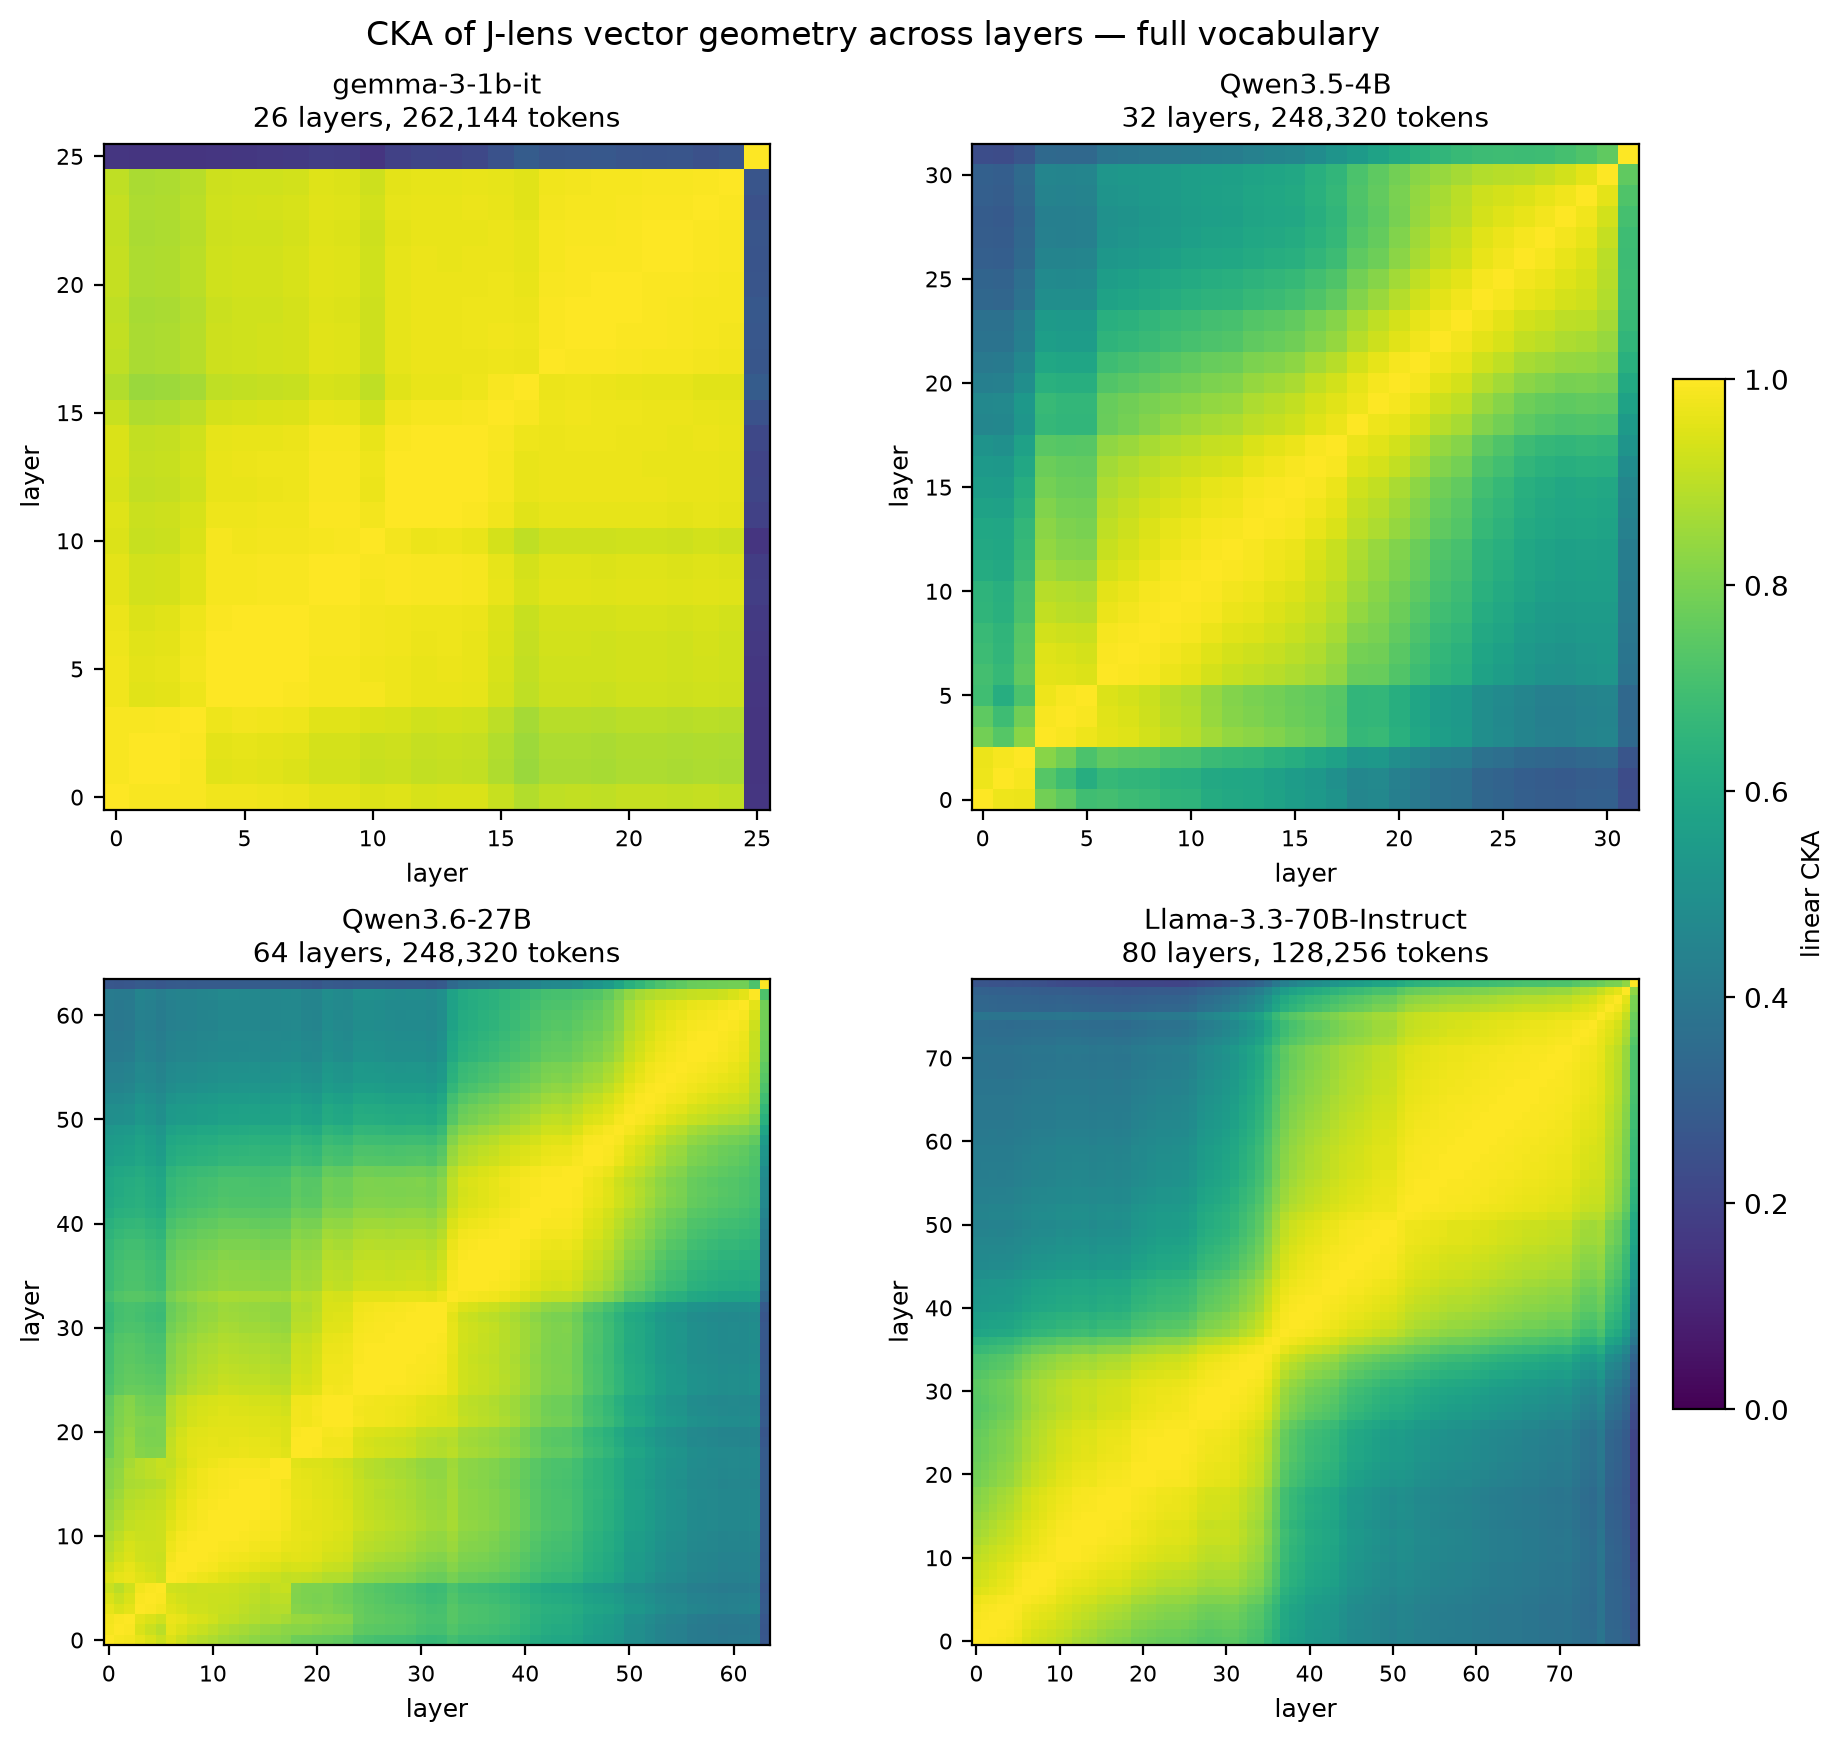

In [5]:
import matplotlib.pyplot as plt


def cka_figure(key, subtitle):
    fig, axes = plt.subplots(2, 2, figsize=(9.6, 8.6), dpi=200,
                             constrained_layout=True)
    for ax, (label, r) in zip(axes.ravel(), results.items()):
        im = ax.imshow(r[key], origin="lower", vmin=0, vmax=1,
                       cmap="viridis", interpolation="nearest")
        n_tok = r["n_word"] if key == "word" else r["vocab"]
        ax.set_title(f"{label}\n{len(r['layers'])} layers, {n_tok:,} tokens",
                     fontsize=10)
        ax.set_xlabel("layer", fontsize=9)
        ax.set_ylabel("layer", fontsize=9)
        ax.tick_params(labelsize=8)
    cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)
    cbar.set_label("linear CKA", fontsize=9)
    fig.suptitle(f"CKA of J-lens vector geometry across layers — {subtitle}",
                 fontsize=12)
    return fig


cka_figure("full", "full vocabulary")
plt.show()


## Word-like tokens

These vocabularies carry large blocks of `<unusedN>` slots, byte-fallback
tokens, and punctuation fragments whose lens directions are essentially noise.
This variant keeps only tokens that decode to word-like strings
(`jlens.vis._meaningful_token_mask`).


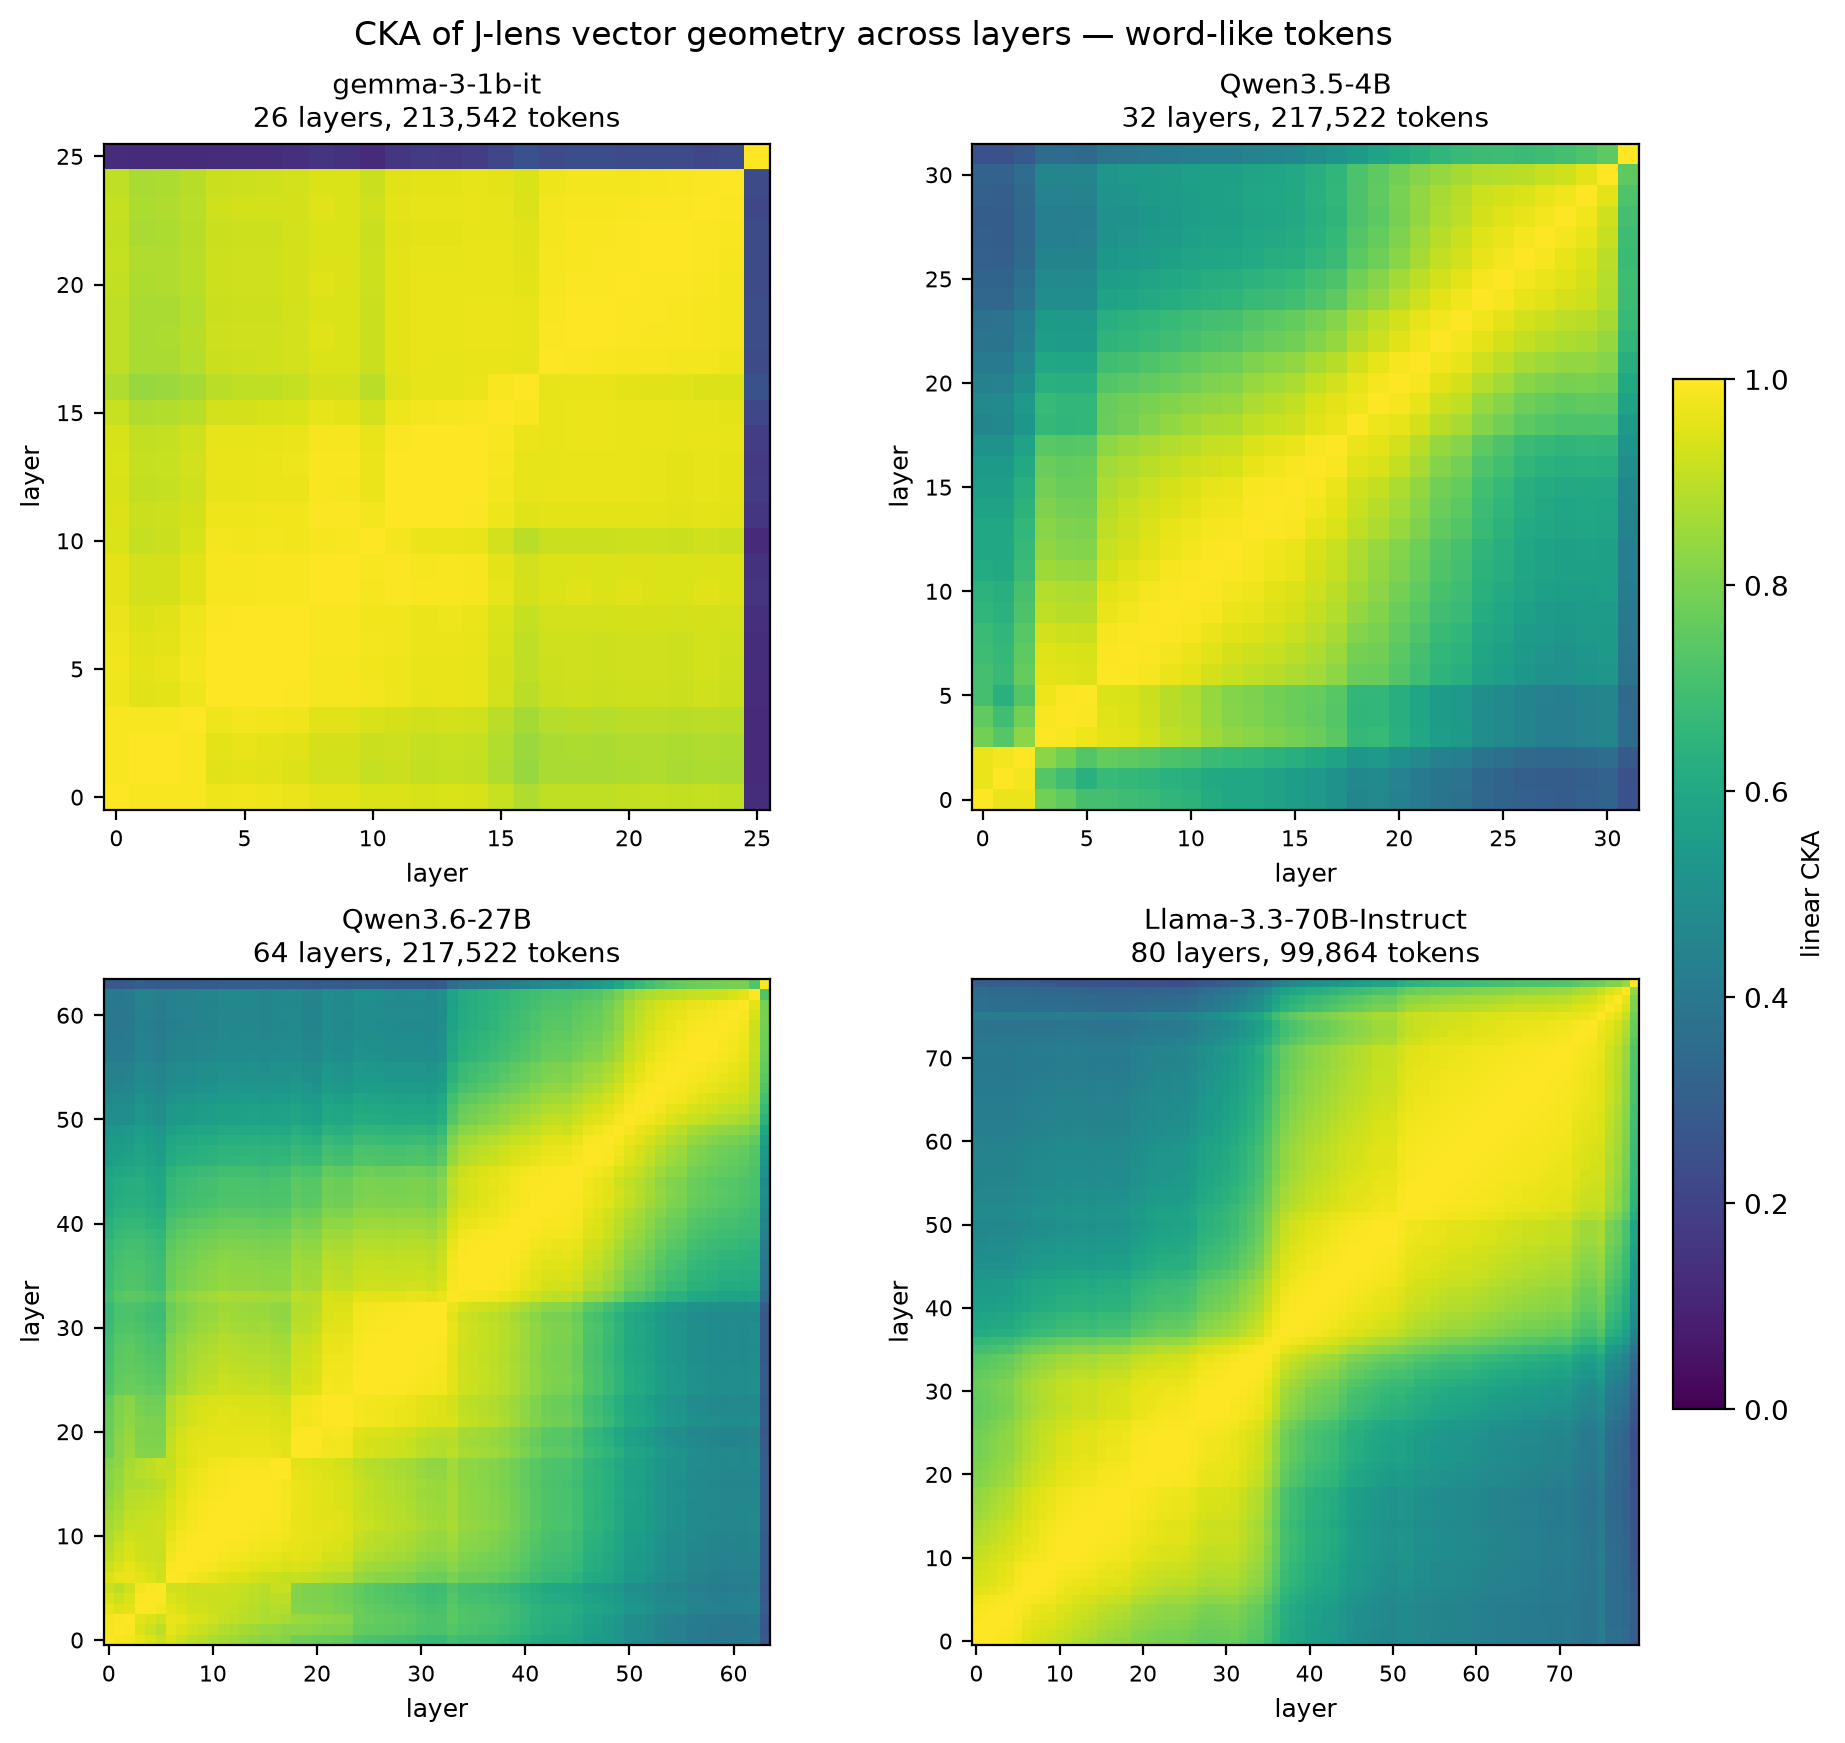

In [6]:
cka_figure("word", "word-like tokens")
plt.show()


## Notes

- The paper does not specify Figure 27's token set or vector normalization, and
  its reference model is far deeper than any of these four, so absolute values
  are not directly comparable; the object of interest is the qualitative
  cross-layer structure.
- Both figures share the [0, 1] color scale, so panels are comparable across
  models and between the two token sets.


## Our own fit vs. the published lens

`scripts/fit_lens.py` reconstructs the command Neuronpedia used for these
lenses. Refitting gemma-3-1b-it with it stops on the same prompt they did
(460 of 1000); the same layer × layer view for our transport and for theirs.
Full vocabulary, no word-like mask.

26 layers, 262,144 tokens; max |ours - theirs| = 6.76e-05   [14s]


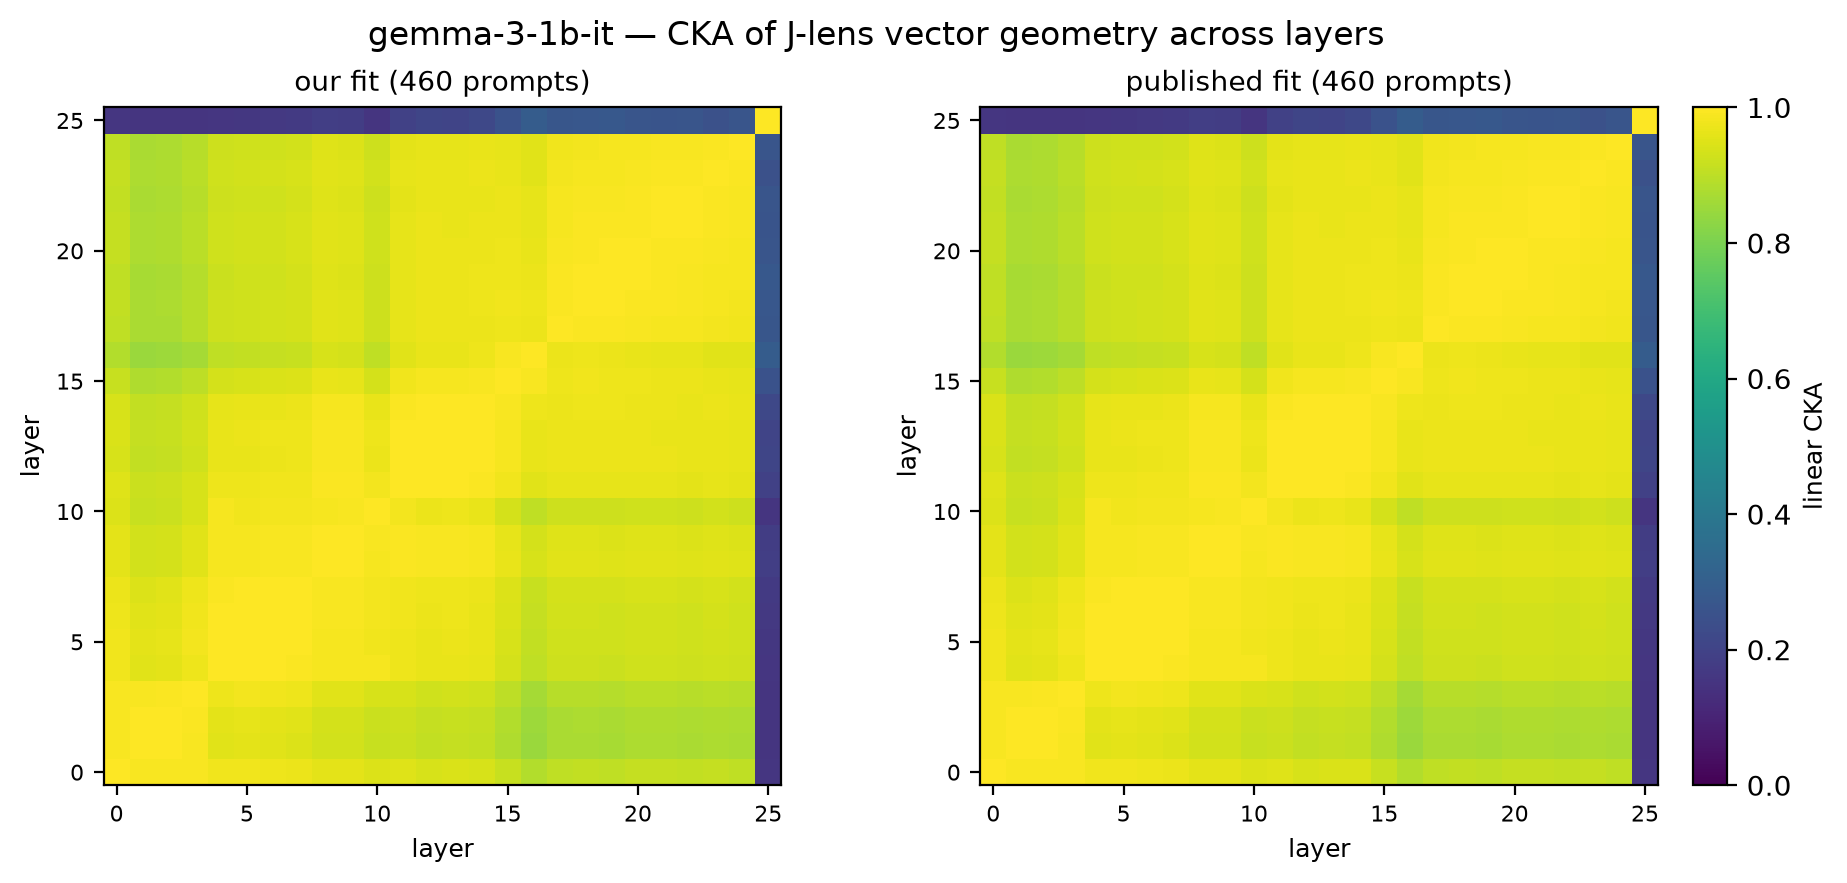

In [7]:
OUTPUT_DIR = next(p for p in ("output", "../output") if os.path.isdir(p))
# Byte-identical to google/gemma-3-1b-it (verified by checkpoint sha256).
GEMMA_LOCAL = "/workspace/models/gemma3_1B/gemma3_1b_ancestor"

t0 = time.time()
W_U, n_layers = load_unembedding(GEMMA_LOCAL)
gemma_ours = jlens.JacobianLens.load(f"{OUTPUT_DIR}/gemma3_1b_ancestor_jacobian_lens.pt")
gemma_theirs = jlens.JacobianLens.from_pretrained(LENS_REPO, filename=MODELS[0][2])
# Both panels are indexed by the same layer list, and `lens_directions` falls
# back to the identity for any layer a lens does not cover — so if the two fits
# covered different layers, the mismatch would show up as extra identity rows
# rather than as an error. Insist they match.
assert list(gemma_theirs.source_layers) == list(gemma_ours.source_layers), (
    gemma_ours.source_layers, gemma_theirs.source_layers)
gemma_layers = list(gemma_ours.source_layers) + [n_layers - 1]

cka_gemma_ours = cka_matrix(W_U, gemma_ours.jacobians, gemma_layers)
cka_gemma_theirs = cka_matrix(W_U, gemma_theirs.jacobians, gemma_layers)
vocab = W_U.shape[0]
del W_U
torch.cuda.empty_cache()

print(f"{len(gemma_layers)} layers, {vocab:,} tokens; "
      f"max |ours - theirs| = {(cka_gemma_ours - cka_gemma_theirs).abs().max():.2e}"
      f"   [{time.time() - t0:.0f}s]")

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.3), dpi=200, constrained_layout=True)
for ax, matrix, title in zip(
        axes, (cka_gemma_ours, cka_gemma_theirs),
        (f"our fit ({gemma_ours.n_prompts} prompts)",
         f"published fit ({gemma_theirs.n_prompts} prompts)")):
    im = ax.imshow(matrix, origin="lower", vmin=0, vmax=1, cmap="viridis",
                   interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("layer", fontsize=9)
    ax.set_ylabel("layer", fontsize=9)
    ax.tick_params(labelsize=8)
fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02).set_label("linear CKA", fontsize=9)
fig.suptitle("gemma-3-1b-it — CKA of J-lens vector geometry across layers",
             fontsize=12)
plt.show()


## Our OLMo 2 fit next to our Gemma 3 fit

The same view for
[allenai/OLMo-2-0425-1B-SFT](https://huggingface.co/allenai/OLMo-2-0425-1B-SFT)
(419 prompts, 16 layers, $d = 2048$) beside gemma-3-1b-it (460 prompts, 26
layers, $d = 1152$), both from our own fits. Two separate matrices on the
shared [0, 1] scale, so the panels are comparable.

OLMo-2-0425-1B-SFT: 16 layers, 100,352 tokens, 419 prompts   [5s]


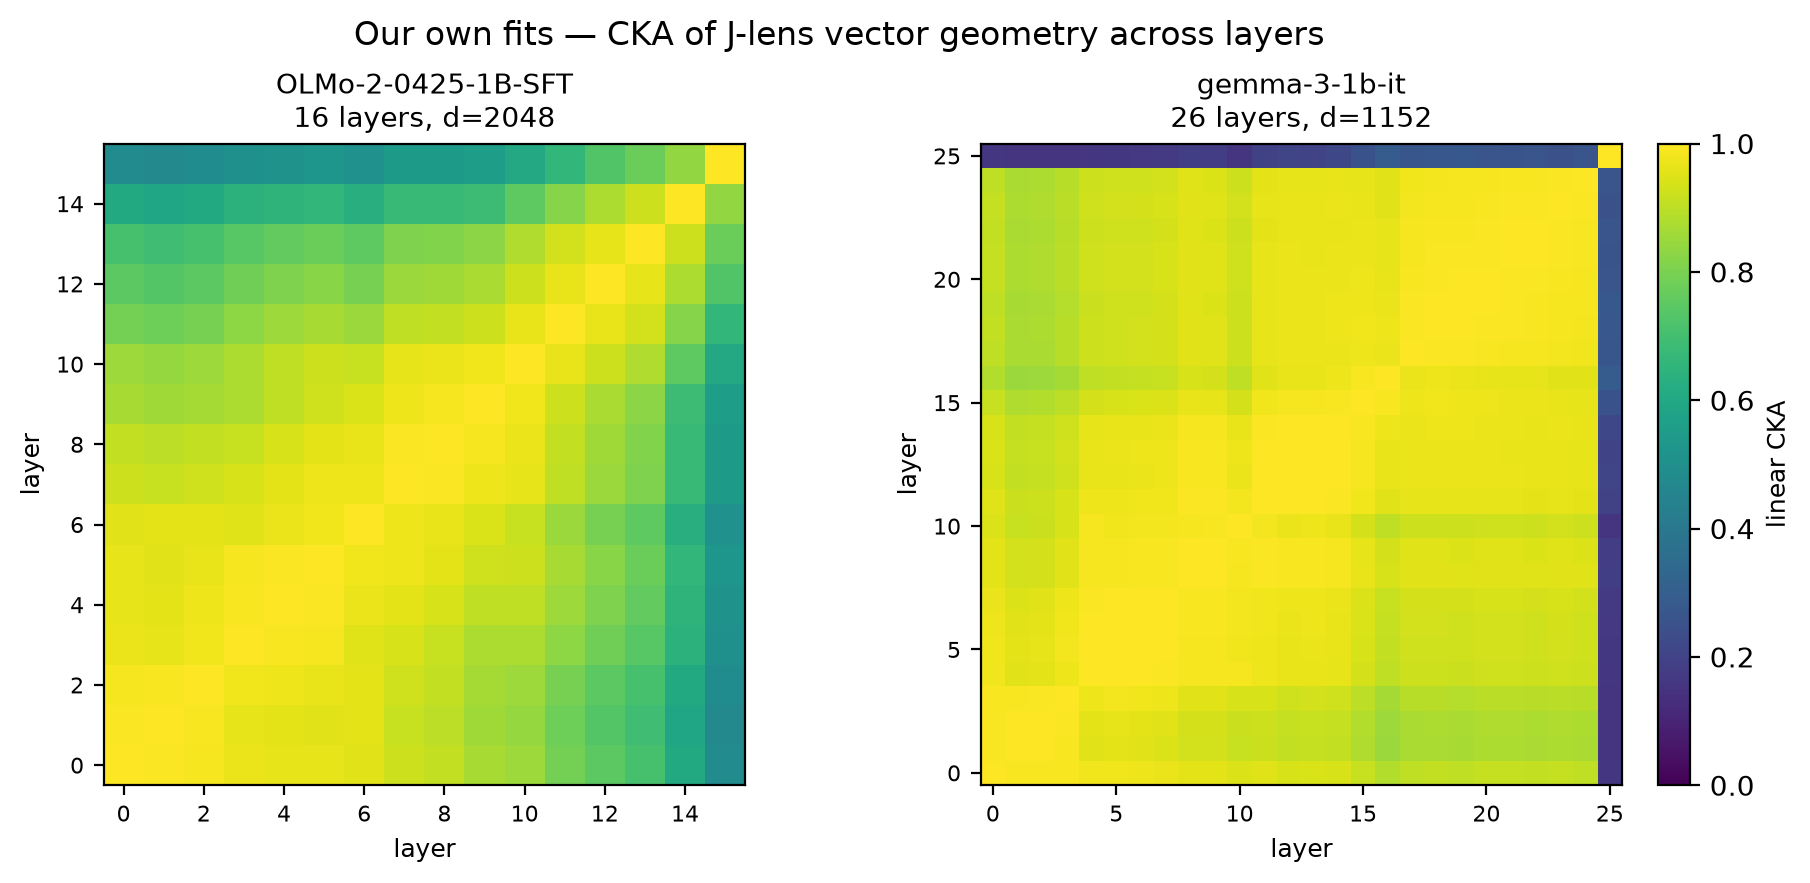

In [8]:
# allenai/OLMo-2-0425-1B-SFT (verified: identical lm_head to the Hub copy).
OLMO_LOCAL = "/workspace/models/olmo2_1B/olmo2_1b_base_sft"


def load_unembedding_bin(source, device="cuda"):
    """`load_unembedding` for a checkpoint stored as a single
    `pytorch_model.bin` rather than safetensors shards, as our olmo2 organisms
    are. Memory-mapped, so only the unembedding is actually read."""
    cfg = json.load(open(fetch(source, "config.json")))
    cfg = cfg.get("text_config", cfg)
    state = torch.load(fetch(source, "pytorch_model.bin"), map_location="cpu",
                       weights_only=True, mmap=True)
    return state[unembed_key(state)].float().to(device), cfg["num_hidden_layers"]


t0 = time.time()
W_U, n_layers = load_unembedding_bin(OLMO_LOCAL)
olmo_ours = jlens.JacobianLens.load(f"{OUTPUT_DIR}/olmo2_1b_base_sft_jacobian_lens.pt")
olmo_layers = list(olmo_ours.source_layers) + [n_layers - 1]

cka_olmo_ours = cka_matrix(W_U, olmo_ours.jacobians, olmo_layers)
vocab = W_U.shape[0]
del W_U
torch.cuda.empty_cache()

print(f"OLMo-2-0425-1B-SFT: {len(olmo_layers)} layers, {vocab:,} tokens, "
      f"{olmo_ours.n_prompts} prompts   [{time.time() - t0:.0f}s]")

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.3), dpi=200, constrained_layout=True)
for ax, matrix, title in zip(
        axes, (cka_olmo_ours, cka_gemma_ours),
        (f"OLMo-2-0425-1B-SFT\n{len(olmo_layers)} layers, d={olmo_ours.d_model}",
         f"gemma-3-1b-it\n{len(gemma_layers)} layers, d={gemma_ours.d_model}")):
    im = ax.imshow(matrix, origin="lower", vmin=0, vmax=1, cmap="viridis",
                   interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("layer", fontsize=9)
    ax.set_ylabel("layer", fontsize=9)
    ax.tick_params(labelsize=8)
fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02).set_label("linear CKA", fontsize=9)
fig.suptitle("Our own fits — CKA of J-lens vector geometry across layers",
             fontsize=12)
plt.show()
